# Installation of required libraries and basic setup

In [ ]:
!pip install tensorflow

In [ ]:
!pip install matplotlib

In [ ]:
import pandas as pd
import numpy as np
import h5py # for reading input images of h5 format.
import glob # used for iterating the folder and getting the correspondinng images.
import matplotlib.pyplot as plt
%matplotlib inline
import tensorflow as tf

In [ ]:
# Make .kaggle directory
!mkdir ~/.kaggle

# Copy the kaggle.json to this directory
!cp /content/kaggle.json ~/.kaggle/

# Set permission
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d tekbahadurkshetri/landslide4sense
!unzip /content/landslide4sense.zip

Streaming output truncated to the last 5000 lines.
  inflating: TrainData/img/image_3558.h5  
  inflating: TrainData/img/image_3559.h5  
  inflating: TrainData/img/image_356.h5  
  inflating: TrainData/img/image_3560.h5  
  inflating: TrainData/img/image_3561.h5  
  inflating: TrainData/img/image_3562.h5  
  inflating: TrainData/img/image_3563.h5  
  inflating: TrainData/img/image_3564.h5  
  inflating: TrainData/img/image_3565.h5  
  inflating: TrainData/img/image_3566.h5  
  inflating: TrainData/img/image_3567.h5  
  inflating: TrainData/img/image_3568.h5  
  inflating: TrainData/img/image_3569.h5  
  inflating: TrainData/img/image_357.h5  
  inflating: TrainData/img/image_3570.h5  
  inflating: TrainData/img/image_3571.h5  
  inflating: TrainData/img/image_3572.h5  
  inflating: TrainData/img/image_3573.h5  
  inflating: TrainData/img/image_3574.h5  
  inflating: TrainData/img/image_3575.h5  
  inflating: TrainData/img/image_3576.h5  
  inflating: TrainData/img/image_3577.h5  
  inf

# Testing the dataset

In [ ]:
# Testing the dataset
path_single = r"/content/TrainData/img/image_1005.h5"
path_single_mask = r'/content/TrainData/mask/mask_1005.h5'

ls ['img']
input data shape: (128, 128, 14)
data ndvi shape  (128, 128) f_data shape:  (1, 128, 128, 3)


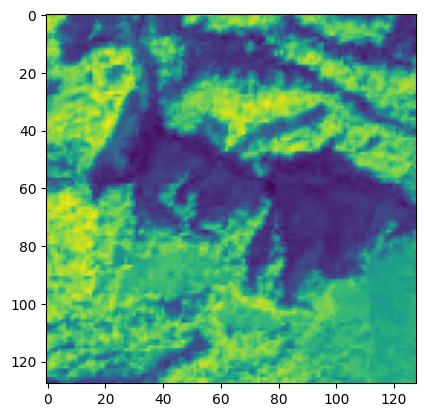

In [ ]:
# Initialize a 4D numpy array with shape (1, 128, 128, 3) filled with zeros
# This is presumably meant to hold processed data (3 channels for each 128x128 image)
f_data = np.zeros((1, 128, 128, 3))

# Open the HDF5 file (path_single) for reading
with h5py.File(path_single) as hdf:
    # Get a list of all datasets inside the HDF5 file
    ls = list(hdf.keys())
    print("ls", ls)  # Print the names of the datasets within the HDF5 file

    # Load the image data from the dataset named 'img' in the HDF5 file
    data = np.array(hdf.get('img'))
    print("input data shape:", data.shape)  # Print the shape of the input image data

    # Display the RGB image using the last three channels of the data array
    # Here, the image is plotted by selecting channels 3, 2, and 1, which is essentially the RGB order
    plt.imshow(data[:, :, 3:0:-1])

    # Extract different bands from the data array
    data_red = data[:, :, 3]   # Red channel (3rd index)
    data_green = data[:, :, 2]  # Green channel (2nd index)
    data_blue = data[:, :, 1]   # Blue channel (1st index)
    data_nir = data[:, :, 7]    # Near-infrared channel (7th index)

    # Create an RGB composite using the red, green, and blue bands (channels 3 to 1)
    data_rgb = data[:, :, 3:0:-1]  # RGB composite image

    # Compute the NDVI (Normalized Difference Vegetation Index)
    # NDVI formula: (NIR - Red) / (NIR + Red)
    epsilon = 1e-10
    data_ndvi = np.divide(data_nir - data_red, np.add(data_nir, data_red) + epsilon)


    # Populate the first channel of the f_data array with the NDVI values
    f_data[0, :, :, 0] = data_ndvi

    # Add additional data (presumably other spectral bands) to the second and third channels of f_data
    f_data[0, :, :, 1] = data[:, :, 12]  # Possibly another spectral band (12th index)
    f_data[0, :, :, 2] = data[:, :, 13]  # Possibly another spectral band (13th index)

    # Print the shapes of the NDVI data and the processed f_data array
    print("data ndvi shape ", data_ndvi.shape, "f_data shape: ", f_data.shape)

    # Display the NDVI image using Matplotlib
    plt.imshow(data_ndvi)

<h2>Code Explanation</h2>
<ul>
  <li>
    <strong>f_data Initialization:</strong>
    The array <code>f_data</code> is initialized to store processed data for a single image of size 128x128 pixels with 3 channels. It will later hold NDVI data and two other spectral bands.
  </li>
  
  <li>
    <strong>HDF5 File Reading:</strong>
    The HDF5 file (<code>path_single</code>) is opened, and the datasets are inspected. The image data is retrieved from the dataset named <code>'img'</code>.
  </li>
  
  <li>
    <strong>Data Extraction:</strong>
    <ul>
      <li><strong>RGB Data:</strong> The RGB channels are extracted (3:0:-1) and displayed using <code>plt.imshow()</code>.</li>
      <li><strong>Spectral Bands:</strong> Individual spectral bands are extracted (red, green, blue, NIR).</li>
    </ul>
  </li>
  
  <li>
    <strong>NDVI Calculation:</strong>
    The NDVI is calculated using the NIR (near-infrared) and red bands with the formula:
    <pre>NDVI = (NIR - Red) / (NIR + Red)</pre>
    The result is assigned to the first channel of <code>f_data</code>.
  </li>
  
  <li>
    <strong>Additional Data:</strong>
    The second and third channels of <code>f_data</code> are filled with data from other spectral bands (possibly thermal or additional satellite bands).
  </li>
  
  <li>
    <strong>Visualizations:</strong>
    The script uses <code>matplotlib</code> to visualize both the RGB composite and the NDVI result.
  </li>
</ul>

ls ['mask']
input data shape: (128, 128)


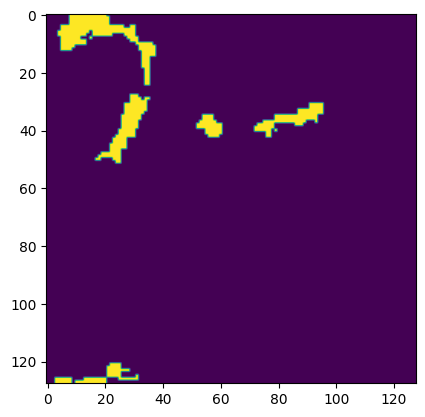

In [ ]:
# Open the HDF5 file (path_single_mask) for reading the mask data
with h5py.File(path_single_mask) as hdf:
    # Get a list of all datasets inside the HDF5 file
    ls = list(hdf.keys())
    print("ls", ls)  # Print the names of the datasets within the HDF5 file

    # Load the mask data from the dataset named 'mask'
    data = np.array(hdf.get('mask'))
    print("input data shape:", data.shape)  # Print the shape of the mask data

    # Display the mask data using Matplotlib
    plt.imshow(data)

<h2>Code Explanation</h2>
<ul>
  <li>
    <strong>HDF5 File Reading:</strong>
    The HDF5 file (<code>path_single_mask</code>) is opened, and a list of datasets inside the file is printed for inspection.
  </li>
  
  <li>
    <strong>Loading Mask Data:</strong>
    The dataset named <code>'mask'</code> is extracted, converted to a NumPy array, and its shape is printed. The mask data likely represents binary or categorical values used for segmentation.
  </li>
  
  <li>
    <strong>Visualization:</strong>
    The mask is displayed using <code>plt.imshow()</code>, giving a visual representation of the mask (typically shown as grayscale or categorical segmentation).
  </li>
</ul>


# Using all dataset

In [ ]:
# Paths to the single image and mask HDF5 files
path_single = r"/content/TrainData/img/image_1000.h5"  # Path to a specific training image
path_single_mask = r'/content/TrainData/mask/mask_1000.h5'  # Path to a specific mask corresponding to the image

# Paths to all images and masks (wildcard for multiple files)
TRAIN_PATH = r"/content/TrainData/img/*.h5"  # Path to all training images (HDF5 format)
TRAIN_MASK = r'/content/TrainData/mask/*.h5'  # Path to all training masks (HDF5 format)

# Initialize arrays to store all training images and masks
# TRAIN_XX will hold 3799 images, each of size 128x128 pixels with 6 channels
TRAIN_XX = np.zeros((3799, 128, 128, 6))

# TRAIN_YY will hold 3799 corresponding masks, each of size 128x128 pixels with a single channel
TRAIN_YY = np.zeros((3799, 128, 128, 1))

# Get a sorted list of all training image file paths that match the wildcard (*.h5)
all_train = sorted(glob.glob(TRAIN_PATH))

# Get a sorted list of all training mask file paths that match the wildcard (*.h5)
all_mask = sorted(glob.glob(TRAIN_MASK))

<h2>Code Explanation</h2>
<ul>
  <li>
    <strong>File Paths:</strong>
    <ul>
      <li><code>path_single</code> and <code>path_single_mask</code>: These variables hold the paths to specific HDF5 files for a single training image and its corresponding mask.</li>
      <li><code>TRAIN_PATH</code> and <code>TRAIN_MASK</code>: These wildcard paths are used to access all HDF5 files in the <code>img</code> and <code>mask</code> directories for the entire training dataset.</li>
    </ul>
  </li>
  
  <li>
    <strong>Training Data Arrays:</strong>
    <ul>
      <li><code>TRAIN_XX</code>: This array is initialized to store 3799 training images, each of size 128x128 pixels, with 6 channels.</li>
      <li><code>TRAIN_YY</code>: This array is initialized to store 3799 masks, where each mask is a single-channel 128x128 image (for segmentation purposes).</li>
    </ul>
  </li>

  <li>
    <strong>Reading All Training Files:</strong>
    <ul>
      <li><code>glob.glob()</code> is used to find all HDF5 files that match the wildcard patterns in <code>TRAIN_PATH</code> and <code>TRAIN_MASK</code>.</li>
      <li>The files are sorted using <code>sorted()</code> to ensure a consistent and predictable order when loading the data.</li>
    </ul>
  </li>
</ul>


## Train with RGB, NDVI, DEM, and Slope


In [ ]:
#testing for google colab GPU
import tensorflow as tf
tf.test.gpu_device_name()

'/device:GPU:0'

In [ ]:
# Iterate over all training images and their corresponding masks
for i, (img, mask) in enumerate(zip(all_train, all_mask)):
    print(i, img, mask)  # Print the index and file paths for the current image and mask

    # Open the HDF5 file for the training image
    with h5py.File(img) as hdf:
        ls = list(hdf.keys())  # List the keys (datasets) in the HDF5 file
        data = np.array(hdf.get('img'))  # Load the image data from the 'img' dataset

        # Assign a small value for NaN values in the data
        data[np.isnan(data)] = 0.000001

        # Normalize the RGB and additional spectral bands
        mid_rgb = data[:, :, 1:4].max() / 2.0  # Calculate midpoint for RGB bands
        mid_slope = data[:, :, 12].max() / 2.0  # Calculate midpoint for slope band
        mid_elevation = data[:, :, 13].max() / 2.0  # Calculate midpoint for elevation band

        # NDVI calculation using NIR and Red bands
        data_red = data[:, :, 3]  # Extract the red band
        data_nir = data[:, :, 7]  # Extract the NIR band
        data_ndvi = np.divide(data_nir - data_red, np.add(data_nir, data_red))  # Calculate NDVI

        # Populate the final array TRAIN_XX with normalized values
        TRAIN_XX[i, :, :, 0] = 1 - data[:, :, 3] / mid_rgb  # Normalize Red channel
        TRAIN_XX[i, :, :, 1] = 1 - data[:, :, 2] / mid_rgb  # Normalize Green channel
        TRAIN_XX[i, :, :, 2] = 1 - data[:, :, 1] / mid_rgb  # Normalize Blue channel
        TRAIN_XX[i, :, :, 3] = data_ndvi  # Assign NDVI channel
        TRAIN_XX[i, :, :, 4] = 1 - data[:, :, 12] / mid_slope  # Normalize Slope channel
        TRAIN_XX[i, :, :, 5] = 1 - data[:, :, 13] / mid_elevation  # Normalize Elevation channel

    # Open the HDF5 file for the corresponding mask
    with h5py.File(mask) as hdf:
        ls = list(hdf.keys())  # List the keys (datasets) in the mask HDF5 file
        data = np.array(hdf.get('mask'))  # Load the mask data
        TRAIN_YY[i, :, :, 0] = data  # Populate the mask array

0 /content/TrainData/img/image_1.h5 /content/TrainData/mask/mask_1.h5
1 /content/TrainData/img/image_10.h5 /content/TrainData/mask/mask_10.h5
2 /content/TrainData/img/image_100.h5 /content/TrainData/mask/mask_100.h5
3 /content/TrainData/img/image_1000.h5 /content/TrainData/mask/mask_1000.h5
4 /content/TrainData/img/image_1001.h5 /content/TrainData/mask/mask_1001.h5
5 /content/TrainData/img/image_1002.h5 /content/TrainData/mask/mask_1002.h5
6 /content/TrainData/img/image_1003.h5 /content/TrainData/mask/mask_1003.h5
7 /content/TrainData/img/image_1004.h5 /content/TrainData/mask/mask_1004.h5
8 /content/TrainData/img/image_1005.h5 /content/TrainData/mask/mask_1005.h5
9 /content/TrainData/img/image_1006.h5 /content/TrainData/mask/mask_1006.h5
10 /content/TrainData/img/image_1007.h5 /content/TrainData/mask/mask_1007.h5
11 /content/TrainData/img/image_1008.h5 /content/TrainData/mask/mask_1008.h5
12 /content/TrainData/img/image_1009.h5 /content/TrainData/mask/mask_1009.h5
13 /content/TrainData

<ipython-input-10-ea4c33d50724>:28: RuntimeWarning: invalid value encountered in divide
  TRAIN_XX[i, :, :, 4] = 1 - data[:, :, 12] / mid_slope  # Normalize Slope channel


1676 /content/TrainData/img/image_2507.h5 /content/TrainData/mask/mask_2507.h5
1677 /content/TrainData/img/image_2508.h5 /content/TrainData/mask/mask_2508.h5
1678 /content/TrainData/img/image_2509.h5 /content/TrainData/mask/mask_2509.h5
1679 /content/TrainData/img/image_251.h5 /content/TrainData/mask/mask_251.h5
1680 /content/TrainData/img/image_2510.h5 /content/TrainData/mask/mask_2510.h5
1681 /content/TrainData/img/image_2511.h5 /content/TrainData/mask/mask_2511.h5
1682 /content/TrainData/img/image_2512.h5 /content/TrainData/mask/mask_2512.h5
1683 /content/TrainData/img/image_2513.h5 /content/TrainData/mask/mask_2513.h5
1684 /content/TrainData/img/image_2514.h5 /content/TrainData/mask/mask_2514.h5
1685 /content/TrainData/img/image_2515.h5 /content/TrainData/mask/mask_2515.h5
1686 /content/TrainData/img/image_2516.h5 /content/TrainData/mask/mask_2516.h5
1687 /content/TrainData/img/image_2517.h5 /content/TrainData/mask/mask_2517.h5
1688 /content/TrainData/img/image_2518.h5 /content/Tra

<ipython-input-10-ea4c33d50724>:21: RuntimeWarning: invalid value encountered in divide
  data_ndvi = np.divide(data_nir - data_red, np.add(data_nir, data_red))  # Calculate NDVI


2279 /content/TrainData/img/image_305.h5 /content/TrainData/mask/mask_305.h5
2280 /content/TrainData/img/image_3050.h5 /content/TrainData/mask/mask_3050.h5
2281 /content/TrainData/img/image_3051.h5 /content/TrainData/mask/mask_3051.h5
2282 /content/TrainData/img/image_3052.h5 /content/TrainData/mask/mask_3052.h5
2283 /content/TrainData/img/image_3053.h5 /content/TrainData/mask/mask_3053.h5
2284 /content/TrainData/img/image_3054.h5 /content/TrainData/mask/mask_3054.h5
2285 /content/TrainData/img/image_3055.h5 /content/TrainData/mask/mask_3055.h5
2286 /content/TrainData/img/image_3056.h5 /content/TrainData/mask/mask_3056.h5
2287 /content/TrainData/img/image_3057.h5 /content/TrainData/mask/mask_3057.h5
2288 /content/TrainData/img/image_3058.h5 /content/TrainData/mask/mask_3058.h5
2289 /content/TrainData/img/image_3059.h5 /content/TrainData/mask/mask_3059.h5
2290 /content/TrainData/img/image_306.h5 /content/TrainData/mask/mask_306.h5
2291 /content/TrainData/img/image_3060.h5 /content/Train

<h2>Code Explanation</h2>
<ul>
  <li>
    <strong>Loop through Images and Masks:</strong>
    The loop iterates through all training images and their corresponding masks, printing the index and file paths for debugging.
  </li>
  
  <li>
    <strong>Load Image Data:</strong>
    The code opens each HDF5 image file and retrieves the data stored in the <code>'img'</code> dataset.
  </li>

  <li>
    <strong>Handling NaN Values:</strong>
    NaN values in the image data are replaced with a very small number (0.000001) to avoid issues during calculations.
  </li>

  <li>
    <strong>Normalization:</strong>
    The maximum values of the RGB, slope, and elevation bands are used to normalize each channel. This helps ensure that the data is scaled appropriately for further processing.
  </li>

  <li>
    <strong>NDVI Calculation:</strong>
    The NDVI is computed using the formula:
    <pre>(NIR - Red) / (NIR + Red)</pre>
    which helps in vegetation analysis and detecting changes in land cover.
  </li>

  <li>
    <strong>Populating Training Data Arrays:</strong>
    The normalized channels and NDVI are stored in the <code>TRAIN_XX</code> array. Each channel is normalized based on its maximum value, ensuring consistency across the dataset.
  </li>

  <li>
    <strong>Load Mask Data:</strong>
    The code opens the corresponding mask file and loads the mask data, populating the <code>TRAIN_YY</code> array.
  </li>
</ul>


## Testing min, max values in train data

In [ ]:
# Normalize the TRAIN_XX array by dividing by its maximum value (commented out)
# TRAIN_XX_n = TRAIN_XX / TRAIN_XX.max()

# Replace NaN values in TRAIN_XX with a small value to avoid issues in training
TRAIN_XX[np.isnan(TRAIN_XX)] = 0.000001

# Print the minimum and maximum values of TRAIN_XX and TRAIN_YY arrays for inspection
print(TRAIN_XX.min(), TRAIN_XX.max(), TRAIN_YY.min(), TRAIN_YY.max())

-1.0 1.0 0.0 1.0


<h2>Code Explanation</h2>
<ul>
  <li>
    <strong>Normalization (Commented Out):</strong>
    The line <code>TRAIN_XX_n = TRAIN_XX / TRAIN_XX.max()</code> is intended to normalize the <code>TRAIN_XX</code> array by dividing each element by the maximum value in the array. This would scale the values to the range [0, 1]. The line is commented out, possibly because the normalization is not currently desired.
  </li>
  
  <li>
    <strong>Handling NaN Values:</strong>
    The line <code>TRAIN_XX[np.isnan(TRAIN_XX)] = 0.000001</code> ensures that any NaN values in the <code>TRAIN_XX</code> array are replaced with a small value (0.000001) to prevent issues during model training or evaluations.
  </li>

  <li>
    <strong>Inspecting Data Ranges:</strong>
    The <code>print</code> statement outputs the minimum and maximum values of both the <code>TRAIN_XX</code> and <code>TRAIN_YY</code> arrays. This is useful for debugging and understanding the data range before training a model.
  </li>
</ul>


## Custom loss function (Dice Loss)

In [ ]:
# def dice_loss(y_true, y_pred):
#     # Cast y_true to float32 to ensure compatibility for calculations
#     y_true = tf.cast(y_true, tf.float32)

#     # Apply the sigmoid function to the predictions to obtain probabilities
#     y_pred = tf.math.sigmoid(y_pred)

#     # Calculate the numerator of the Dice coefficient
#     numerator = 2 * tf.reduce_sum(y_true * y_pred)

#     # Calculate the denominator of the Dice coefficient
#     denominator = tf.reduce_sum(y_true + y_pred)

#     # Compute and return the Dice loss
#     return 1 - numerator / denominator

<h2>Function: Dice Loss</h2>
<pre>
<code>
def dice_loss(y_true, y_pred):
    # Cast y_true to float32 to ensure compatibility for calculations
    y_true = tf.cast(y_true, tf.float32)
    
    # Apply the sigmoid function to the predictions to obtain probabilities
    y_pred = tf.math.sigmoid(y_pred)

    # Calculate the numerator of the Dice coefficient
    numerator = 2 * tf.reduce_sum(y_true * y_pred)

    # Calculate the denominator of the Dice coefficient
    denominator = tf.reduce_sum(y_true + y_pred)

    # Compute and return the Dice loss
    return 1 - numerator / denominator
</code>
</pre>
<ul>
  <li>
    <strong>Input Casting:</strong>
    The line <code>y_true = tf.cast(y_true, tf.float32)</code> ensures that the true labels (<code>y_true</code>) are cast to a floating-point format to avoid type conflicts.
  </li>
  
  <li>
    <strong>Sigmoid Activation:</strong>
    <code>y_pred = tf.math.sigmoid(y_pred)</code> applies the sigmoid function to the predicted values to transform them into probabilities between 0 and 1.
  </li>

  <li>
    <strong>Numerator Calculation:</strong>
    The numerator is calculated as <code>numerator = 2 * tf.reduce_sum(y_true * y_pred)</code>, emphasizing the importance of true positives.
  </li>

  <li>
    <strong>Denominator Calculation:</strong>
    The denominator is calculated as <code>denominator = tf.reduce_sum(y_true + y_pred)</code>, which provides the total count of positive samples.
  </li>

  <li>
    <strong>Dice Loss Calculation:</strong>
    The function returns <code>1 - numerator / denominator</code>, computing the Dice loss, a measure of overlap between true and predicted positives.
  </li>
</ul>


## Visualization of the training data

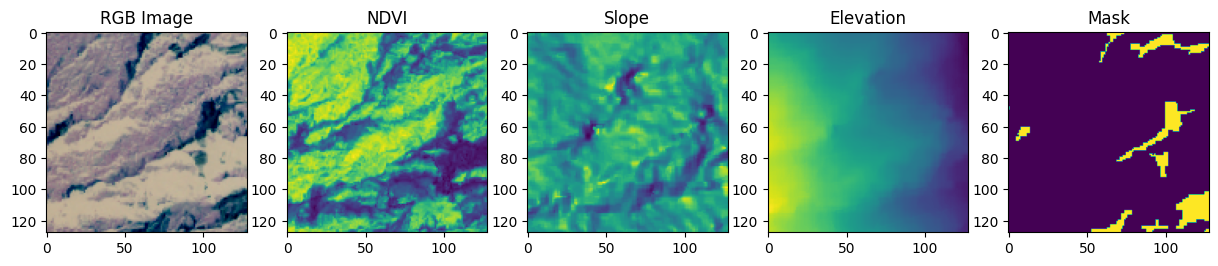

In [ ]:
# Set the index of the image to visualize
img = 234

# Create a figure with 5 subplots arranged in a single row
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(15, 10))

# Set titles for each subplot
ax1.set_title("RGB Image")
ax2.set_title("NDVI")
ax3.set_title("Slope")
ax4.set_title("Elevation")
ax5.set_title("Mask")

# Display the RGB channels of the selected image
ax1.imshow(TRAIN_XX[img, :, :, 0:3])  # Displays the first three channels (RGB)

# Display the NDVI channel of the selected image
ax2.imshow(TRAIN_XX[img, :, :, 3])    # Displays the NDVI channel

# Display the Slope channel of the selected image
ax3.imshow(TRAIN_XX[img, :, :, 4])    # Displays the Slope channel

# Display the Elevation channel of the selected image
ax4.imshow(TRAIN_XX[img, :, :, 5])     # Displays the Elevation channel

# Display the Mask of the selected image
ax5.imshow(TRAIN_YY[img, :, :, 0])     # Displays the ground truth mask

<h2>Visualization of Image Channels</h2>
<ul>
  <li>
    <strong>Image Selection:</strong>
    The variable <code>img = 234</code> sets the index of the image to be visualized.
  </li>
  
  <li>
    <strong>Subplot Creation:</strong>
    <code>plt.subplots(1, 5, figsize=(15, 10))</code> creates a figure with one row and five columns of subplots.
  </li>

  <li>
    <strong>Setting Titles:</strong>
    Each subplot has a title set using <code>ax.set_title("Title")</code> for easy identification.
  </li>

  <li>
    <strong>Displaying Images:</strong>
    <code>ax1.imshow(TRAIN_XX[img, :, :, 0:3])</code> displays the RGB image and the subsequent <code>imshow</code> calls show the NDVI, Slope, Elevation, and Mask images.
  </li>
</ul>


## Validation split

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and validation sets
x_train, x_valid, y_train, y_valid = train_test_split(TRAIN_XX, TRAIN_YY, test_size=0.2, shuffle=True)

<h2>Data Splitting using train_test_split</h2>

<ul>
  <li>
    <strong>Importing the Function:</strong>
    The line <code>from sklearn.model_selection import train_test_split</code> imports the function used for splitting datasets.
  </li>
  
  <li>
    <strong>Data Splitting:</strong>
    The line <code>x_train, x_valid, y_train, y_valid = train_test_split(TRAIN_XX, TRAIN_YY, test_size=0.2, shuffle=True)</code> splits the dataset into training (80%) and validation (20%) sets.
    <ul>
      <li><code>TRAIN_XX</code>: The input feature array containing the training data.</li>
      <li><code>TRAIN_YY</code>: The target array containing the ground truth masks.</li>
      <li><code>test_size=0.2</code>: Specifies that 20% of the data should be reserved for validation.</li>
      <li><code>shuffle=True</code>: Ensures that the data is shuffled before splitting.</li>
    </ul>
  </li>
</ul>


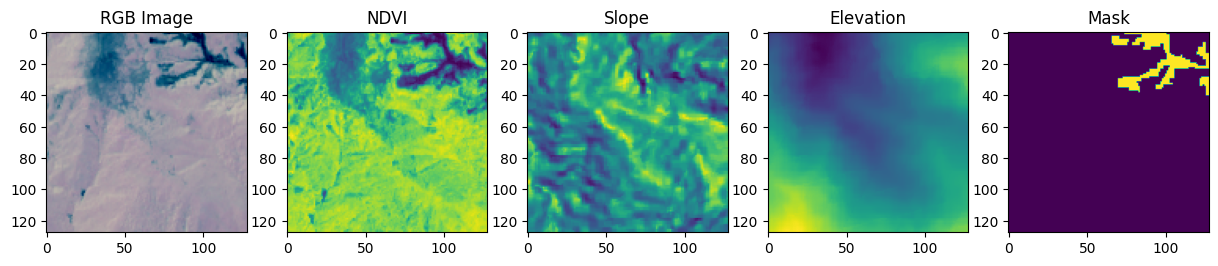

In [ ]:
# Set the index of the image to visualize
img = 1545

# Create a figure with 5 subplots arranged in a single row
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(15, 10))

# Set titles for each subplot
ax1.set_title("RGB Image")
ax2.set_title("NDVI")
ax3.set_title("Slope")
ax4.set_title("Elevation")
ax5.set_title("Mask")

# Display the RGB channels of the selected training image
ax1.imshow(x_train[img, :, :, 0:3])  # Displays the first three channels (RGB)

# Display the NDVI channel of the selected training image
ax2.imshow(x_train[img, :, :, 3])    # Displays the NDVI channel

# Display the Slope channel of the selected training image
ax3.imshow(x_train[img, :, :, 4])    # Displays the Slope channel

# Display the Elevation channel of the selected training image
ax4.imshow(x_train[img, :, :, 5])    # Displays the Elevation channel

# Display the Mask of the selected training image
ax5.imshow(y_train[img, :, :, 0])     # Displays the ground truth mask

<h2>Visualization of Training Image Channels</h2>

<ul>
  <li>
    <strong>Image Selection:</strong>
    The variable <code>img = 1545</code> sets the index of the image to be visualized from the training dataset.
  </li>
  
  <li>
    <strong>Subplot Creation:</strong>
    <code>plt.subplots(1, 5, figsize=(15, 10))</code> creates a figure with one row and five columns of subplots.
  </li>

  <li>
    <strong>Setting Titles:</strong>
    Each subplot has a title set using <code>ax.set_title("Title")</code> for easy identification.
  </li>

  <li>
    <strong>Displaying Images:</strong>
    Each <code>ax.imshow()</code> function call displays a specific channel of the selected image, including RGB, NDVI, Slope, Elevation, and the Mask.
  </li>
</ul>


In [ ]:
x_train.shape, y_train.shape

((3039, 128, 128, 6), (3039, 128, 128, 1))

In [ ]:
# To release some memory, delete the unnecessary variables
del TRAIN_XX    # Deletes the TRAIN_XX variable to free up memory
del TRAIN_YY    # Deletes the TRAIN_YY variable to free up memory
del all_train    # Deletes the all_train variable to free up memory
del all_mask     # Deletes the all_mask variable to free up memory

<h2>Memory Management: Deleting Unnecessary Variables</h2>

<ul>
  <li>
    <strong>Memory Management:</strong>
    The <code>del</code> statement is used to delete variables that are no longer needed in the code to manage memory usage.
  </li>
  
  <li>
    <strong>Variable Deletion:</strong>
    Each <code>del</code> statement removes a specific variable to free up memory, which can be important when working with large datasets.
  </li>

  <li>
    <strong>Benefits:</strong>
    Deleting unnecessary variables helps to release memory resources that may otherwise lead to memory constraints during processing or model training.
  </li>
</ul>


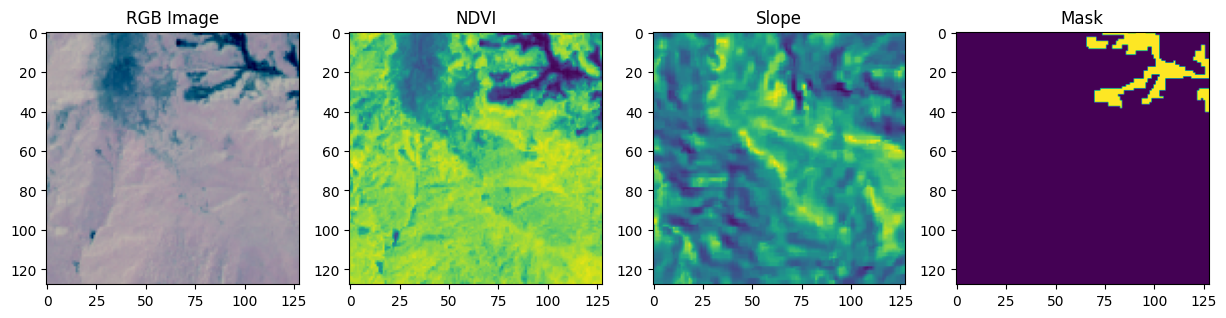

In [ ]:
# Set the index of the image to visualize
img = 1545

# Create a figure with 4 subplots arranged in a single row
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(15, 10))

# Set titles for each subplot
ax1.set_title("RGB Image")
ax2.set_title("NDVI")
ax3.set_title("Slope")
ax4.set_title("Mask")

# Display the RGB channels of the selected training image
ax1.imshow(x_train[img, :, :, 0:3])  # Displays the first three channels (RGB)

# Display the NDVI channel of the selected training image
ax2.imshow(x_train[img, :, :, 3])    # Displays the NDVI channel

# Display the Slope channel of the selected training image
ax3.imshow(x_train[img, :, :, 4])    # Displays the Slope channel

# Display the Mask of the selected training image
ax4.imshow(y_train[img, :, :, 0])     # Displays the ground truth mask

<h2>Visualization of Training Image Channels</h2>

<ul>
  <li>
    <strong>Image Selection:</strong>
    The variable <code>img = 1545</code> sets the index of the image to be visualized from the training dataset.
  </li>
  
  <li>
    <strong>Subplot Creation:</strong>
    <code>plt.subplots(1, 4, figsize=(15, 10))</code> creates a figure with one row and four columns of subplots.
  </li>

  <li>
    <strong>Setting Titles:</strong>
    Each subplot has a title set using <code>ax.set_title("Title")</code> for easy identification.
  </li>

  <li>
    <strong>Displaying Images:</strong>
    Each <code>ax.imshow()</code> function call displays a specific channel of the selected image, including RGB, NDVI, Slope, and the Mask.
  </li>
</ul>


# Unet Model

In [ ]:
from utils import recall_m, precision_m, f1_m
import tensorflow as tf

def unet_model(IMG_WIDTH, IMG_HIGHT, IMG_CHANNELS):
    # Input layer for the U-Net model
    inputs = tf.keras.layers.Input((IMG_WIDTH, IMG_HIGHT, IMG_CHANNELS))

    # Contraction path (downsampling)
    c1 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    c1 = tf.keras.layers.Dropout(0.1)(c1)
    c1 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    p1 = tf.keras.layers.MaxPooling2D((2, 2))(c1)

    c2 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = tf.keras.layers.Dropout(0.1)(c2)
    c2 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    p2 = tf.keras.layers.MaxPooling2D((2, 2))(c2)

    c3 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = tf.keras.layers.Dropout(0.2)(c3)
    c3 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    p3 = tf.keras.layers.MaxPooling2D((2, 2))(c3)

    c4 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
    c4 = tf.keras.layers.Dropout(0.2)(c4)
    c4 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
    p4 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(c4)

    c5 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
    c5 = tf.keras.layers.Dropout(0.3)(c5)
    c5 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)

    # Expansive path (upsampling)
    u6 = tf.keras.layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = tf.keras.layers.concatenate([u6, c4])
    c6 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = tf.keras.layers.Dropout(0.2)(c6)
    c6 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)

    u7 = tf.keras.layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = tf.keras.layers.concatenate([u7, c3])
    c7 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = tf.keras.layers.Dropout(0.2)(c7)
    c7 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)

    u8 = tf.keras.layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = tf.keras.layers.concatenate([u8, c2])
    c8 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
    c8 = tf.keras.layers.Dropout(0.1)(c8)
    c8 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)

    u9 = tf.keras.layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = tf.keras.layers.concatenate([u9, c1], axis=3)
    c9 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
    c9 = tf.keras.layers.Dropout(0.1)(c9)
    c9 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)

    # Output layer
    outputs = tf.keras.layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)

    # Create the model
    model = tf.keras.Model(inputs=[inputs], outputs=[outputs])

    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', f1_m, precision_m, recall_m])

    return model


In [ ]:
# Create the U-Net model
model = unet_model(128, 128, 6)

# Print the model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 6)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 128, 128, 16)   │            880 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 128, 128, 16)   │              0 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 128, 128, 16)   │          2,320 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 64, 64, 16)     │              0 │ conv2d_1[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 64, 64, 32)     │          4,640 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 64, 64, 32)     │              0 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 64, 64, 32)     │          9,248 │ dropout_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 32, 32, 32)     │              0 │ conv2d_3[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 32, 32, 64)     │         18,496 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, 32, 32, 64)     │              0 │ conv2d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 32, 32, 64)     │         36,928 │ dropout_2[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 16, 16, 64)     │              0 │ conv2d_5[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 16, 16, 128)    │         73,856 │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_3 (Dropout)       │ (None, 16, 16, 128)    │              0 │ conv2d_6[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 16, 16, 128)    │        147,584 │ dropout_3[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 8, 8, 128)      │              0 │ conv2d_7[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)    

 Total params: 1,941,537 (7.41 MB)

 Trainable params: 1,941,537 (7.41 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# model = unet_model(128, 128, 6)
# # model.summary()
# checkpointer = tf.keras.callbacks.ModelCheckpoint("best_model.h5", monitor="val_f1_m", verbose=1, save_best_only=True, mode="max")
# # earlyStopping = tf.keras.callbacks.EarlyStopping(monitor='val_f1_m', patience=10, verbose=1, mode='max')

# callbacks = [
#     # earlyStopping,
#     checkpointer
#     ]
# history = model.fit(x_train, y_train, batch_size=16,
#           epochs=100,
#           verbose = 2,
#           validation_data=(x_valid, y_valid),
#           callbacks=callbacks)

# model.save("model_save.h5")

In [ ]:
model = unet_model(128, 128, 6)

checkpointer = tf.keras.callbacks.ModelCheckpoint("best_model.keras", monitor="val_f1_m", verbose=1, save_best_only=True, mode="max")
callbacks = [
    # earlyStopping,
    checkpointer
    ]
history = model.fit(x_train, y_train, batch_size=16,
          epochs=100,
          verbose = 2,
          validation_data=(x_valid, y_valid),
          callbacks=callbacks)

model.save("model_save.keras") # Also change the filename here

Epoch 1/100

Epoch 1: val_f1_m improved from -inf to 0.60042, saving model to best_model.keras
190/190 - 58s - 307ms/step - accuracy: 0.9795 - f1_m: 0.2147 - loss: 0.0598 - precision_m: 0.5202 - recall_m: 0.1719 - val_accuracy: 0.9826 - val_f1_m: 0.6004 - val_loss: 0.0513 - val_precision_m: 0.6954 - val_recall_m: 0.5422
Epoch 2/100

Epoch 2: val_f1_m improved from 0.60042 to 0.66387, saving model to best_model.keras
190/190 - 38s - 199ms/step - accuracy: 0.9843 - f1_m: 0.5772 - loss: 0.0433 - precision_m: 0.7091 - recall_m: 0.5109 - val_accuracy: 0.9834 - val_f1_m: 0.6639 - val_loss: 0.0442 - val_precision_m: 0.6535 - val_recall_m: 0.6821
Epoch 3/100

Epoch 3: val_f1_m did not improve from 0.66387
190/190 - 10s - 53ms/step - accuracy: 0.9858 - f1_m: 0.6237 - loss: 0.0380 - precision_m: 0.7275 - recall_m: 0.5637 - val_accuracy: 0.9846 - val_f1_m: 0.6598 - val_loss: 0.0388 - val_precision_m: 0.7211 - val_recall_m: 0.6170
Epoch 4/100

Epoch 4: val_f1_m did not improve from 0.66387
190/190

In [ ]:
loss, accuracy, f1_score, precision, recall = model.evaluate(x_valid, y_valid, verbose=0)
print(loss, accuracy, f1_score, precision, recall)

0.0381980836391449 0.987023115158081 0.7180060744285583 0.8003703951835632 0.6537842154502869


In [ ]:
# Evaluate the model
metrics = model.evaluate(x_valid, y_valid, verbose=0)
metric_names = ['Loss', 'Accuracy', 'F1 Score', 'Precision', 'Recall']

# Evaluate the validation metrics
val_metrics = ['val_loss', 'val_accuracy', 'val_f1_m', 'val_precision_m', 'val_recall_m']
val_results = [history.history[key][-1] for key in val_metrics]

# Print the results in a tabular format
print(f"{'Metric':<20} {'Training':<20} {'Validation':<20}")
print("="*60)
for name, train_value, val_value in zip(metric_names, metrics, val_results):
    print(f"{name:<20} {train_value:<20.4f} {val_value:<20.4f}")


Metric               Training             Validation          
Loss                 0.0382               0.0382              
Accuracy             0.9870               0.9870              
F1 Score             0.7180               0.7087              
Precision            0.8004               0.7936              
Recall               0.6538               0.6460              


#Dice Coefficient

In [ ]:
import numpy as np

def dice_coefficient(y_true, y_pred, threshold=0.5):
    """
    Calculate the Dice Coefficient.

    Args:
        y_true (np.array): Ground truth labels.
        y_pred (np.array): Predicted labels.
        threshold (float): Threshold to binarize predictions.

    Returns:
        float: Dice Coefficient value.
    """
    y_pred_bin = (y_pred > threshold).astype(np.uint8)
    intersection = np.sum(y_true * y_pred_bin)
    dice = (2 * intersection) / (np.sum(y_true) + np.sum(y_pred_bin) + 1e-7)
    return dice

# Example usage
dice = dice_coefficient(y_valid, model.predict(x_valid))
print("Dice Coefficient:", dice)


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Dice Coefficient: 0.7216012074180544


In [ ]:
dice = dice_coefficient(y_valid, model.predict(x_valid))
iou = iou_score(y_valid, model.predict(x_valid))

print(f"{'Metric':<20}{'Value':<10}")
print("-" * 30)
print(f"{'Loss':<20}{loss:<10.4f}")
print(f"{'Accuracy':<20}{accuracy:<10.4f}")
print(f"{'F1 Score':<20}{f1_score:<10.4f}")
print(f"{'Precision':<20}{precision:<10.4f}")
print(f"{'Recall':<20}{recall:<10.4f}")
print(f"{'Dice Coefficient':<20}{dice:<10.4f}")


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Metric              Value     
------------------------------
Loss                0.0382    
Accuracy            0.9870    
F1 Score            0.7180    
Precision           0.8004    
Recall              0.6538    
Dice Coefficient    0.7216    


# Prediction

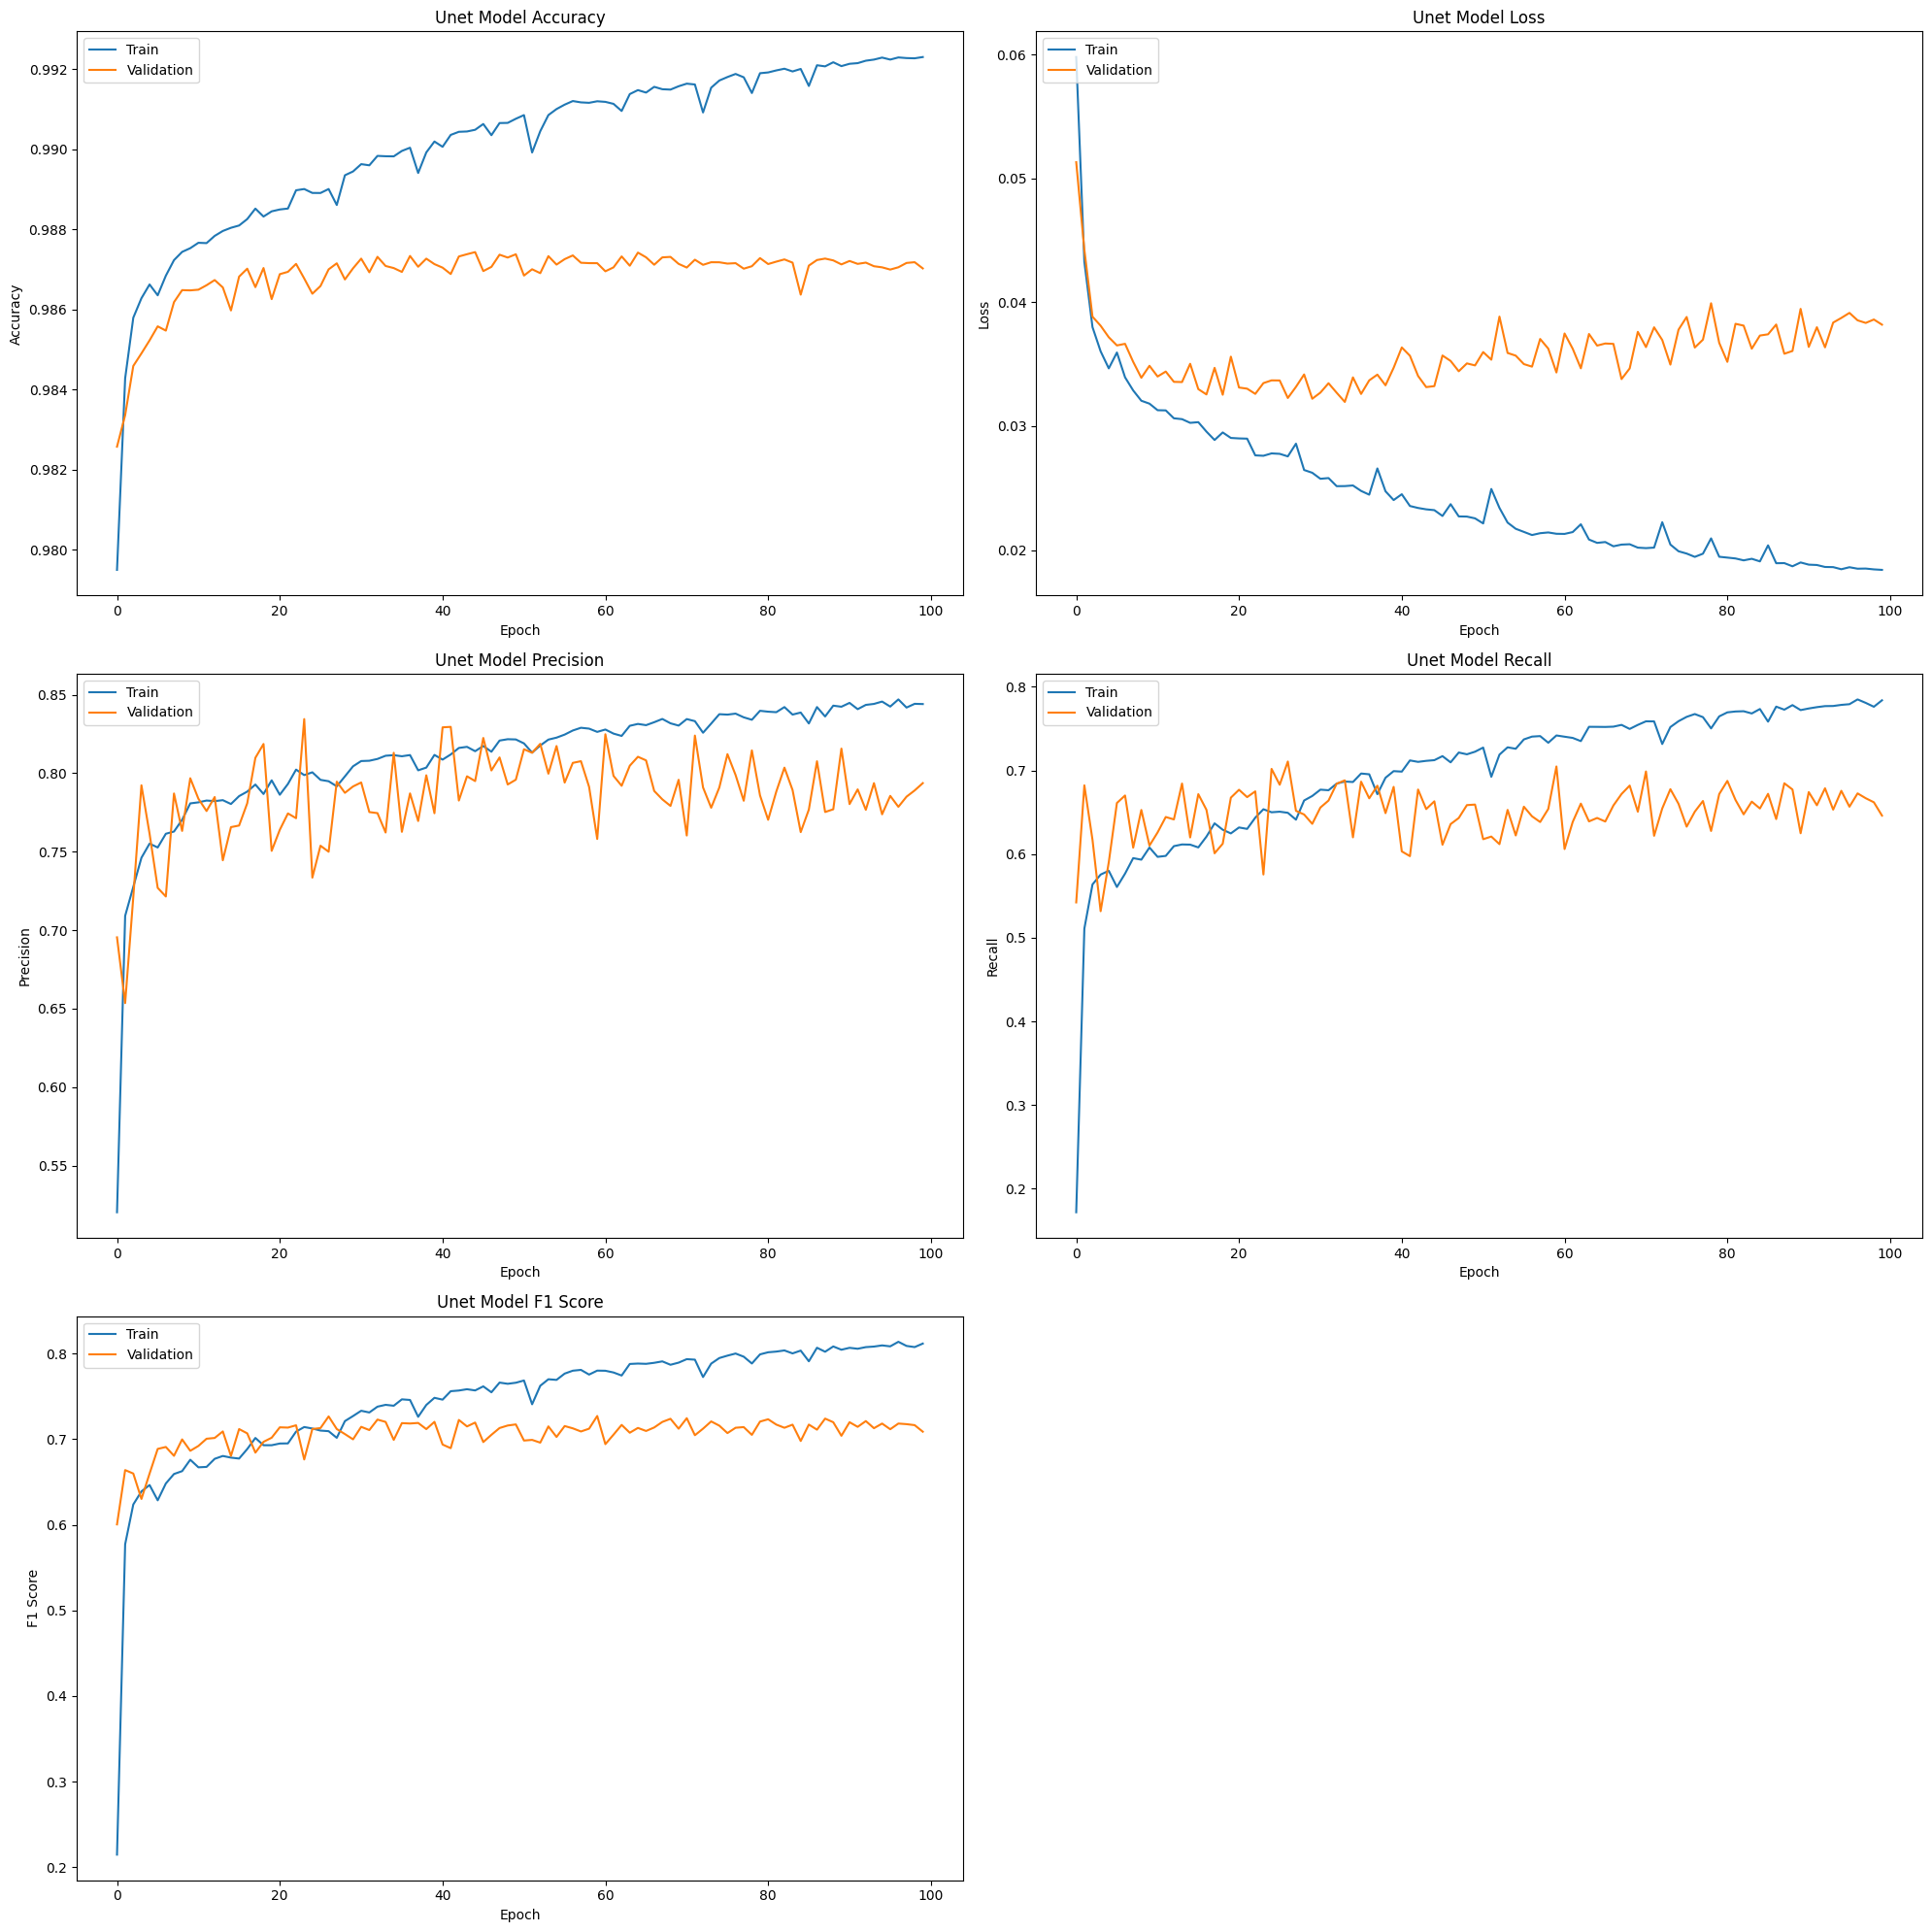

In [ ]:
fig, ((ax11, ax12), (ax13, ax14), (ax15, ax16)) = plt.subplots(3, 2, figsize=(20, 20))

# Plot accuracy
ax11.plot(history.history['accuracy'])
ax11.plot(history.history['val_accuracy'])
ax11.title.set_text('Unet Model Accuracy')
ax11.set_ylabel('Accuracy')
ax11.set_xlabel('Epoch')
ax11.legend(['Train', 'Validation'], loc='upper left')

# Plot loss
ax12.plot(history.history['loss'])
ax12.plot(history.history['val_loss'])
ax12.title.set_text('Unet Model Loss')
ax12.set_ylabel('Loss')
ax12.set_xlabel('Epoch')
ax12.legend(['Train', 'Validation'], loc='upper left')

# Plot precision
ax13.plot(history.history['precision_m'])
ax13.plot(history.history['val_precision_m'])
ax13.set_title('Unet Model Precision')
ax13.set_ylabel('Precision')
ax13.set_xlabel('Epoch')
ax13.legend(['Train', 'Validation'], loc='upper left')

# Plot recall
ax14.plot(history.history['recall_m'])
ax14.plot(history.history['val_recall_m'])
ax14.set_title('Unet Model Recall')
ax14.set_ylabel('Recall')
ax14.set_xlabel('Epoch')
ax14.legend(['Train', 'Validation'], loc='upper left')

# Plot F1 score
ax15.plot(history.history['f1_m'])
ax15.plot(history.history['val_f1_m'])
ax15.set_title('Unet Model F1 Score')
ax15.set_ylabel('F1 Score')
ax15.set_xlabel('Epoch')
ax15.legend(['Train', 'Validation'], loc='upper left')

# Empty axis (if required, you can add another plot here)
ax16.axis('off')  # Remove this subplot if not needed

plt.tight_layout()
plt.show()


In [ ]:
threshold = 0.5
pred_img = model.predict(x_valid)
pred_img = (pred_img > threshold).astype(np.uint8)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


Text(0.5, 1.0, 'Training Image')

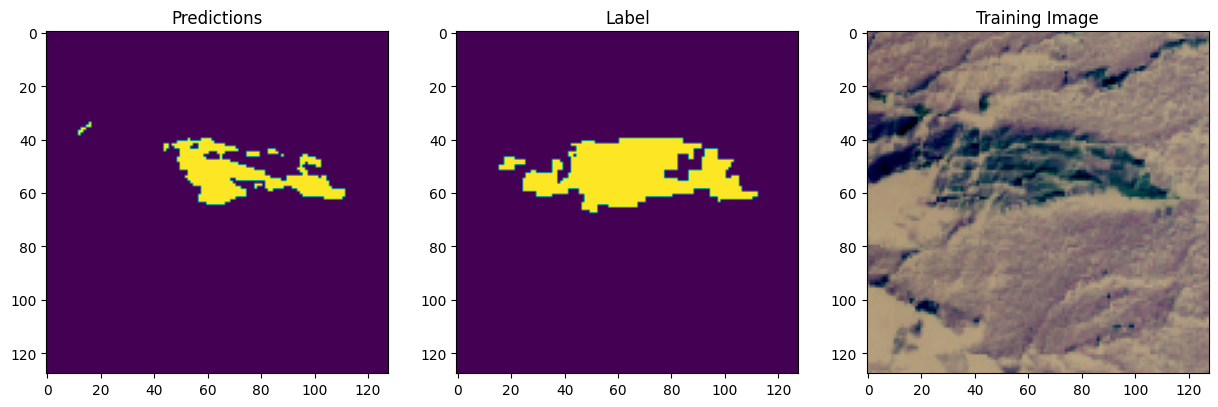

In [ ]:
img = 100
fig,(ax1,ax2,ax3)= plt.subplots(1,3,figsize=(15,10))
ax1.imshow(pred_img[img, :, :, 0])
ax1.set_title("Predictions")
ax2.imshow(y_valid[img, :, :, 0])
ax2.set_title("Label")
ax3.imshow(x_valid[img, :, :, 0:3])
ax3.set_title('Training Image')

# Validation data

In [ ]:
validation_url = r'/content/ValidData/img/*.h5'
img_val = sorted(glob.glob(validation_url))

VAL_XX = np.zeros((245, 128, 128, 6))
mask_name = []
for i, img in enumerate(img_val):
    print(i, img)
    mask_name.append(img.split('/')[-1].replace('image', 'mask'))
    with h5py.File(img) as hdf:
        ls = list(hdf.keys())
        data = np.array(hdf.get('img'))

        # assign 0 for the nan value
        data[np.isnan(data)] = 0.000001

        # to normalize the data
        mid_rgb = data[:, :, 1:4].max() / 2.0
        mid_slope = data[:, :, 12].max() / 2.0
        mid_elevation = data[:, :, 13].max() / 2.0

        # ndvi calculation
        data_red = data[:, :, 3]
        data_nir = data[:, :, 7]
        data_ndvi = np.divide(data_nir - data_red,np.add(data_nir, data_red))

        # final array
        VAL_XX[i, :, :, 0] = 1 - data[:, :, 3] / mid_rgb #RED
        VAL_XX[i, :, :, 1] = 1 - data[:, :, 2] / mid_rgb #GREEN
        VAL_XX[i, :, :, 2] = 1 - data[:, :, 1] / mid_rgb #BLUE
        VAL_XX[i, :, :, 3] = data_ndvi #NDVI
        VAL_XX[i, :, :, 4] = 1- data[:, :, 13] / mid_slope #SLOPE
        VAL_XX[i, :, :, 5] = 1 - data[:, :, 13] / mid_elevation #ELEVATION

0 /content/ValidData/img/image_1.h5
1 /content/ValidData/img/image_10.h5
2 /content/ValidData/img/image_100.h5
3 /content/ValidData/img/image_101.h5
4 /content/ValidData/img/image_102.h5
5 /content/ValidData/img/image_103.h5
6 /content/ValidData/img/image_104.h5
7 /content/ValidData/img/image_105.h5
8 /content/ValidData/img/image_106.h5
9 /content/ValidData/img/image_107.h5
10 /content/ValidData/img/image_108.h5
11 /content/ValidData/img/image_109.h5
12 /content/ValidData/img/image_11.h5
13 /content/ValidData/img/image_110.h5
14 /content/ValidData/img/image_111.h5
15 /content/ValidData/img/image_112.h5
16 /content/ValidData/img/image_113.h5
17 /content/ValidData/img/image_114.h5
18 /content/ValidData/img/image_115.h5
19 /content/ValidData/img/image_116.h5
20 /content/ValidData/img/image_117.h5
21 /content/ValidData/img/image_118.h5
22 /content/ValidData/img/image_119.h5
23 /content/ValidData/img/image_12.h5
24 /content/ValidData/img/image_120.h5
25 /content/ValidData/img/image_121.h5
2

<ipython-input-48-78dff8cbfb58>:24: RuntimeWarning: invalid value encountered in divide
  data_ndvi = np.divide(data_nir - data_red,np.add(data_nir, data_red))


165 /content/ValidData/img/image_27.h5
166 /content/ValidData/img/image_28.h5
167 /content/ValidData/img/image_29.h5
168 /content/ValidData/img/image_3.h5
169 /content/ValidData/img/image_30.h5
170 /content/ValidData/img/image_31.h5
171 /content/ValidData/img/image_32.h5
172 /content/ValidData/img/image_33.h5
173 /content/ValidData/img/image_34.h5
174 /content/ValidData/img/image_35.h5
175 /content/ValidData/img/image_36.h5
176 /content/ValidData/img/image_37.h5
177 /content/ValidData/img/image_38.h5
178 /content/ValidData/img/image_39.h5
179 /content/ValidData/img/image_4.h5
180 /content/ValidData/img/image_40.h5
181 /content/ValidData/img/image_41.h5
182 /content/ValidData/img/image_42.h5
183 /content/ValidData/img/image_43.h5
184 /content/ValidData/img/image_44.h5
185 /content/ValidData/img/image_45.h5
186 /content/ValidData/img/image_46.h5
187 /content/ValidData/img/image_47.h5
188 /content/ValidData/img/image_48.h5
189 /content/ValidData/img/image_49.h5
190 /content/ValidData/img/

## Prediction for validation data

In [ ]:
threshold = 0.5
pred_img = model.predict(VAL_XX)
pred_img = (pred_img > threshold).astype(np.uint8)
pred_img.shape

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 318ms/step


(245, 128, 128, 1)

## Visualization of validation image

Text(0.5, 1.0, 'Training Image')

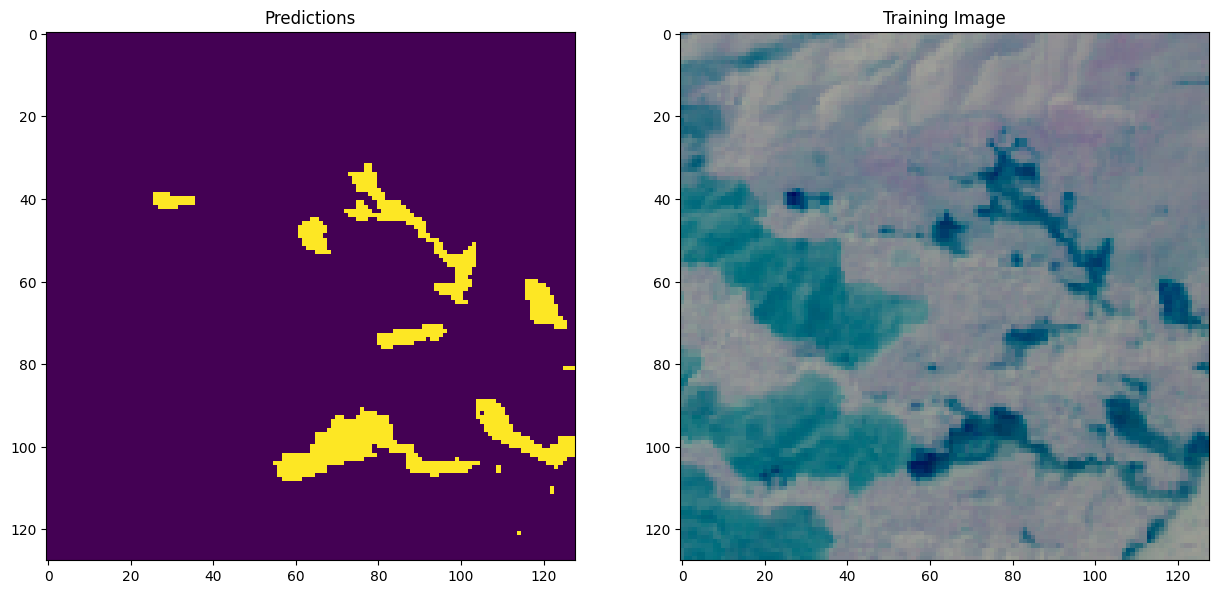

In [ ]:
img = 87
fig,(ax1,ax2)= plt.subplots(1,2,figsize=(15,10))
ax1.imshow(pred_img[img, :, :, 0])
ax1.set_title("Predictions")
ax2.imshow(VAL_XX[img, :, :, 0:3])
ax2.set_title('Training Image')


This code snippet is saving the predicted masks generated by the model into HDF5 files in a specified directory for later use.

In [ ]:
# write_directory = r'/content/gdrive/MyDrive/DL/landslide4Sense/data/validation/mask'
# for i, name in enumerate(mask_name):
#   h5f = h5py.File(write_directory + "/" + name, 'w')
#   # change the dimention of prediction to (n, 128, 128)
#   pred_mask = pred_img[i, :, :, 0]

#   # write to the directory
#   h5f.create_dataset('mask', data = pred_mask)
#   h5f.close()

Thank you!